In [1]:
!pip install statsmodels

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

In [5]:
import pandas as pd

df = pd.read_csv("/superstore_sales.csv")

df.head()

,Order Date,Sales,Category,Region
0,2023-01-01,1200,Technology,West
1,2023-02-01,1500,Furniture,East
2,2023-03-01,1800,Office Supplies,Central
3,2023-04-01,2100,Technology,South
4,2023-05-01,2400,Furniture,West


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Order Date  24 non-null     object
 1   Sales       24 non-null     int64 
 2   Category    24 non-null     object
 3   Region      24 non-null     object
dtypes: int64(1), object(3)
memory usage: 900.0+ bytes


In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [8]:
df.head()

,Order Date,Sales,Category,Region
0,2023-01-01,1200,Technology,West
1,2023-02-01,1500,Furniture,East
2,2023-03-01,1800,Office Supplies,Central
3,2023-04-01,2100,Technology,South
4,2023-05-01,2400,Furniture,West


In [9]:
monthly_sales = df.groupby("Order Date")["Sales"].sum()

monthly_sales

,Sales
Order Date,
2023-01-01,1200
2023-02-01,1500
2023-03-01,1800
2023-04-01,2100
2023-05-01,2400
2023-06-01,2700
2023-07-01,3000
2023-08-01,3300
2023-09-01,3600


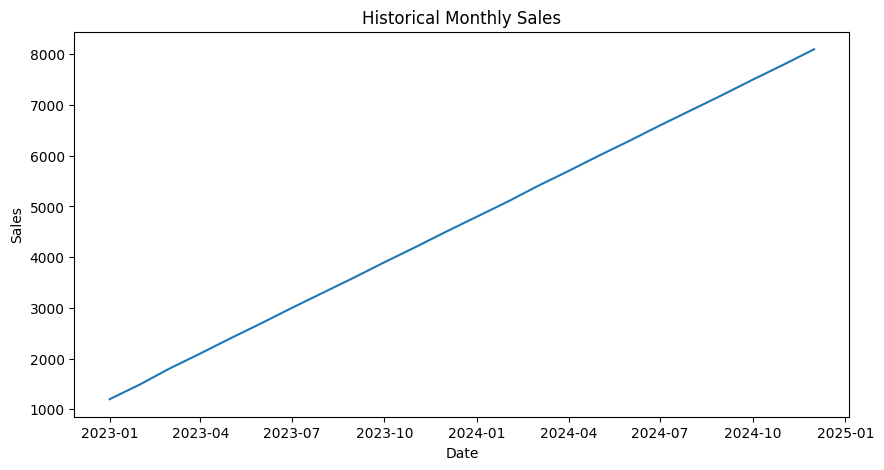

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(monthly_sales)

plt.title("Historical Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [11]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    monthly_sales,
    order=(2,1,2)
)

model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. 

In [12]:
forecast = model_fit.get_forecast(
    steps=12
)

forecast_values = forecast.predicted_mean

confidence_interval = forecast.conf_int()

forecast_values

,predicted_mean
2025-01-01,8399.999483
2025-02-01,8699.998037
2025-03-01,8999.995645
2025-04-01,9299.992324
2025-05-01,9599.988057
2025-06-01,9899.982861
2025-07-01,10199.976720
2025-08-01,10499.969649
2025-09-01,10799.961633
2025-10-01,11099.952687


In [13]:
forecast_df = pd.DataFrame({
    "Date": forecast_values.index,
    "Forecast_Sales": forecast_values.values,
    "Lower_Bound": confidence_interval.iloc[:,0].values,
    "Upper_Bound": confidence_interval.iloc[:,1].values
})

forecast_df

,Date,Forecast_Sales,Lower_Bound,Upper_Bound
0,2025-01-01,8399.999483,8399.858503,8400.140463
1,2025-02-01,8699.998037,8699.580177,8700.415897
2,2025-03-01,8999.995645,8999.221859,9000.769431
3,2025-04-01,9299.992324,9298.802647,9301.182000
4,2025-05-01,9599.988057,9598.325381,9601.650734
5,2025-06-01,9899.982861,9897.800267,9902.165455
6,2025-07-01,10199.976720,10197.227419,10202.726021
7,2025-08-01,10499.969649,10496.613864,10503.325434
8,2025-09-01,10799.961633,10795.958790,10803.964476
9,2025-10-01,11099.952687,11095.267650,11104.637724


In [14]:
forecast_df.to_csv(
    "forecast_results.csv",
    index=False
)

In [15]:
import os

os.listdir()

['.config', 'forecast_results.csv', 'sample_data']

In [16]:
from google.colab import files

files.download("forecast_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>